# Cheminformatics Portfolio Workflow

This notebook is the clean, GitHub-ready workflow for the adsorption capacity project.

It highlights three capabilities relevant to chemical data science roles:

1. **RDKit molecular featurization**: descriptors, fingerprints, and chemical-space plots.
2. **ChemBERTa embeddings**: optional transformer embeddings from SMILES.
3. **Unstructured-to-structured extraction**: parsing messy chemical records into tabular data.

It also keeps the final adsorption modeling workflow: physics-aware features, model comparison, SHAP/applicability-domain hooks, and the hybrid Langmuir + ML model.


In [1]:
from pathlib import Path
import sys
import re
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ec_biochar_adsorption_raw.csv"
FIG_DIR = PROJECT_ROOT / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load and clean the adsorption dataset


In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = [c.strip() for c in df_raw.columns]

print("Raw shape:", df_raw.shape)
display(df_raw.head())


Raw shape: (3757, 29)


,Adsorbent,Pyrolysis temperature,Pyrolysis time,C,H,O,N,(O+N)/C,Ash,H/C,...,RPM,Volume,Adsorbent dosage,Adsorption temperature,Ion concentration,Humic acid,Wastewater type,Adsorption type,Final concentration,Capacity
0,PB600,600,120,78.79,2.12,3.38,1.99,0.068156,19.09,0.32,...,150,0.025,0.02,25,0.0,0,Synthetic,Single,1.089202,-4.460094
1,PB600,600,120,78.79,2.12,3.38,1.99,0.068156,19.09,0.32,...,150,0.025,0.04,25,0.0,0,Synthetic,Single,0.572770,10.680751
2,PB600,600,120,78.79,2.12,3.38,1.99,0.068156,19.09,0.32,...,150,0.025,0.08,25,0.0,0,Synthetic,Single,0.361502,7.981221
3,PB600,600,120,78.79,2.12,3.38,1.99,0.068156,19.09,0.32,...,150,0.025,0.12,25,0.0,0,Synthetic,Single,0.291080,5.907668
4,PB600,600,120,78.79,2.12,3.38,1.99,0.068156,19.09,0.32,...,150,0.025,0.16,25,0.0,0,Synthetic,Single,0.197183,5.017606


In [3]:
df = df_raw.copy()

# Convert numeric columns that may have been read as object.
categorical_cols = ["Adsorbent", "Pollutant", "Wastewater type", "Adsorption type"]
for col in df.columns:
    if col not in categorical_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep physically meaningful positive adsorption capacities.
df = df.dropna(subset=["Capacity"])
df = df[df["Capacity"] > 0].reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Capacity range:", df["Capacity"].min(), "to", df["Capacity"].max())


Cleaned shape: (3673, 29)
Capacity range: 0.194920312 to 536.3388486


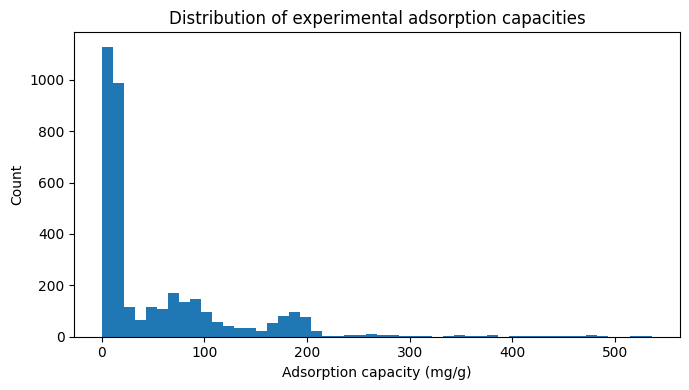

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["Capacity"], bins=50)
ax.set_xlabel("Adsorption capacity (mg/g)")
ax.set_ylabel("Count")
ax.set_title("Distribution of experimental adsorption capacities")
fig.tight_layout()
fig.savefig(FIG_DIR / "capacity_distribution.png", dpi=200)
plt.show()


## 2. RDKit molecular descriptors and fingerprints

This section demonstrates a standard cheminformatics workflow:

- map pollutant abbreviations to SMILES,
- calculate interpretable RDKit descriptors,
- generate Morgan fingerprints,
- visualize chemical space.


In [8]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

POLLUTANT_SMILES = {
    "IBU": "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O",
    "IBF": "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O",
    "CBZ": "NC(=O)N1c2ccccc2C=Cc3ccccc31",
    "DCF": "O=C(O)Cc1ccccc1Nc2c(Cl)cccc2Cl",
    "EE2": "C#CC1(O)CCC2C3CCC4=CC(=O)CCC4C3CCC21C",
    "NPX": "COc1ccc2ccccc2c1C(C)C(=O)O",
    "NXP": "COc1ccc2ccccc2c1C(C)C(=O)O",
    "ATE": "CC(C)NCC(O)COc1ccc(CC(N)=O)cc1",
    "SMX": "Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1",
    "CIP": "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "BPA": "CC(C)(c1ccc(O)cc1)c2ccc(O)cc2",
    "ATZ": "CCNc1nc(Cl)nc(NC(C)C)n1",
}

def mol_from_smiles(smiles):
    if not isinstance(smiles, str) or not smiles:
        return None
    return Chem.MolFromSmiles(smiles)

def rdkit_descriptors(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return {
            "mol_weight": np.nan,
            "logp": np.nan,
            "tpsa": np.nan,
            "hbd": np.nan,
            "hba": np.nan,
            "num_rings": np.nan,
            "aromatic_rings": np.nan,
            "rotatable_bonds": np.nan,
            "formal_charge": np.nan,
        }
    return {
        "mol_weight": Descriptors.MolWt(mol),
        "logp": Crippen.MolLogP(mol),
        "tpsa": rdMolDescriptors.CalcTPSA(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "hba": Lipinski.NumHAcceptors(mol),
        "num_rings": rdMolDescriptors.CalcNumRings(mol),
        "aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol),
        "formal_charge": Chem.GetFormalCharge(mol),
    }

df["smiles"] = df["Pollutant"].map(POLLUTANT_SMILES)
desc = df["smiles"].apply(rdkit_descriptors).apply(pd.Series)

# Fill descriptor columns only if missing or mostly missing.
for col in desc.columns:
    if col not in df.columns or df[col].isna().mean() > 0.5:
        df[col] = desc[col]

selected_pollutants = ["IBU", "IBF", "CBZ", "DCF", "EE2", "NPX", "NXP", "ATE", "SMX", "CIP", "BPA", "ATZ"]

print("SMILES coverage:", df["smiles"].notna().mean().round(3))

display(
    df[df["Pollutant"].isin(selected_pollutants)][
        ["Pollutant", "smiles", "mol_weight", "logp", "tpsa", "hbd", "hba", "num_rings"]
    ]
    .drop_duplicates()
)


SMILES coverage: 0.759


,Pollutant,smiles,mol_weight,logp,tpsa,hbd,hba,num_rings
0,IBF,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,206.285,3.0732,37.30,1.0,1.0,1.0
14,CBZ,NC(=O)N1c2ccccc2C=Cc3ccccc31,236.274,3.3872,46.33,1.0,1.0,3.0
1218,ATE,CC(C)NCC(O)COc1ccc(CC(N)=O)cc1,266.341,0.4521,84.58,3.0,4.0,1.0
1560,EE2,C#CC1(O)CCC2C3CCC4=CC(=O)CCC4C3CCC21C,298.426,3.4925,37.30,1.0,2.0,4.0
2300,NXP,COc1ccc2ccccc2c1C(C)C(=O)O,230.263,3.0365,46.53,1.0,2.0,2.0
2324,DCF,O=C(O)Cc1ccccc1Nc2c(Cl)cccc2Cl,296.153,4.3641,49.33,2.0,2.0,2.0
2348,IBU,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,206.285,3.0732,37.30,1.0,1.0,1.0
2489,NPX,COc1ccc2ccccc2c1C(C)C(=O)O,230.263,3.0365,46.53,1.0,2.0,2.0


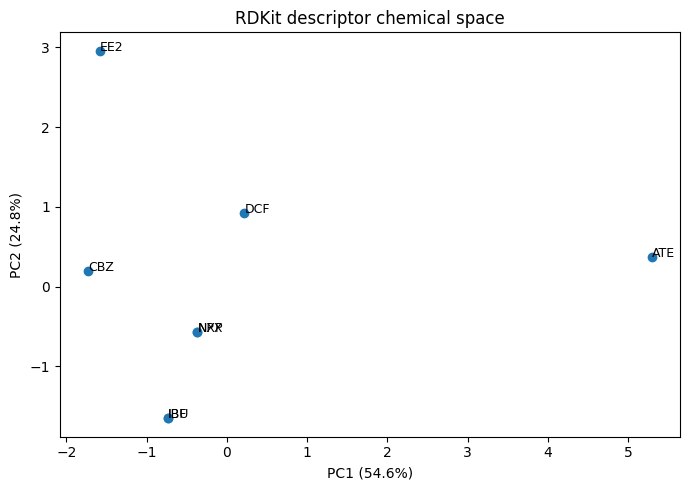

In [9]:
descriptor_cols = ["mol_weight", "logp", "tpsa", "hbd", "hba", "num_rings", "aromatic_rings", "rotatable_bonds"]

desc_unique = (
    df.dropna(subset=["smiles"])
      .drop_duplicates("Pollutant")
      .set_index("Pollutant")[descriptor_cols]
      .dropna()
)

scaled = StandardScaler().fit_transform(desc_unique)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(scaled)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coords[:, 0], coords[:, 1])
for pollutant, x, y in zip(desc_unique.index, coords[:, 0], coords[:, 1]):
    ax.text(x, y, pollutant, fontsize=9)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("RDKit descriptor chemical space")
fig.tight_layout()
fig.savefig(FIG_DIR / "rdkit_descriptor_pca.png", dpi=200)
plt.show()


This PCA plot shows the chemical space of selected pollutants based on RDKit descriptors. 
PC1 mainly captures hydrophobicity and molecular size, while PC2 reflects polarity and functional groups. 
We can see that compounds cluster based on structural similarity, and outliers like atenolol highlight very different adsorption behavior, which justifies using flexible models and feature engineering.

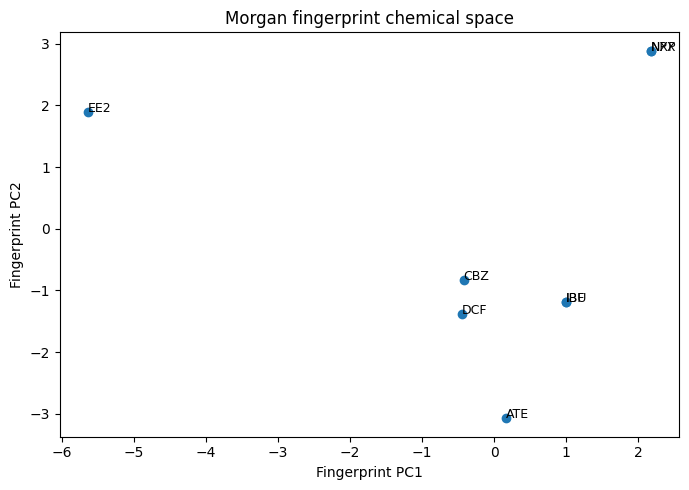

In [10]:
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

unique_mols = df.dropna(subset=["smiles"]).drop_duplicates("Pollutant")[["Pollutant", "smiles"]].copy()
fps = []
labels = []
for _, row in unique_mols.iterrows():
    mol = Chem.MolFromSmiles(row["smiles"])
    if mol is None:
        continue
    fp = generator.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fps.append(arr)
    labels.append(row["Pollutant"])

fp_matrix = np.vstack(fps)
fp_coords = PCA(n_components=2, random_state=42).fit_transform(fp_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fp_coords[:, 0], fp_coords[:, 1])
for label, x, y in zip(labels, fp_coords[:, 0], fp_coords[:, 1]):
    ax.text(x, y, label, fontsize=9)
ax.set_xlabel("Fingerprint PC1")
ax.set_ylabel("Fingerprint PC2")
ax.set_title("Morgan fingerprint chemical space")
fig.tight_layout()
fig.savefig(FIG_DIR / "morgan_fingerprint_pca.png", dpi=200)
plt.show()


This plot shows chemical space based on Morgan fingerprints, which encode molecular substructures. Unlike descriptor-based PCA, this representation captures structural similarity directly. We observe clustering of structurally related compounds like CBZ and DCF (aromatic, multi-ring pharmaceuticals), while distinct molecules like EE2 (steroid structure → large, fused rings) and atenolol appear as outliers. This is important because adsorption behavior is strongly influenced by molecular structure.

## 3. ChemBERTa molecular embeddings

This section demonstrates how a pre-trained domain-specific model can be incorporated.

The cell is optional: if model weights are unavailable, the workflow skips gracefully. In a production project, embeddings should be cached and versioned.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


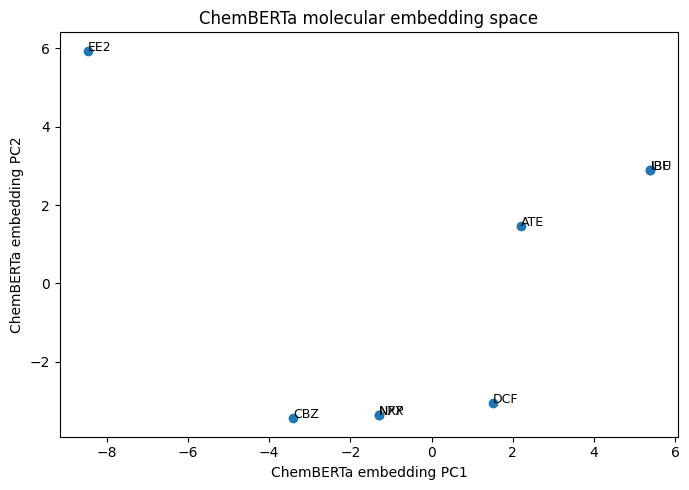

In [11]:
try:
    from src.chemberta_embeddings import load_or_create_chemberta_cache

    chemberta_cache = PROCESSED_DIR / "chemberta_embeddings.npy"
    smiles_unique = unique_mols["smiles"].astype(str).reset_index(drop=True)

    chemberta_emb = load_or_create_chemberta_cache(smiles_unique, chemberta_cache)
    chemberta_coords = PCA(n_components=2, random_state=42).fit_transform(chemberta_emb)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(chemberta_coords[:, 0], chemberta_coords[:, 1])
    for label, x, y in zip(unique_mols["Pollutant"], chemberta_coords[:, 0], chemberta_coords[:, 1]):
        ax.text(x, y, label, fontsize=9)
    ax.set_xlabel("ChemBERTa embedding PC1")
    ax.set_ylabel("ChemBERTa embedding PC2")
    ax.set_title("ChemBERTa molecular embedding space")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "chemberta_embedding_pca.png", dpi=200)
    plt.show()

except Exception as exc:
    print("ChemBERTa embedding step skipped.")
    print("Reason:", exc)
    print("This is expected if transformers/torch/model weights are not available locally.")


ChemBERTa embeddings are learned representations from a transformer model trained on SMILES strings.
Interpretation:
Captures both structure and context-dependent chemical patterns
Learns higher-level relationships beyond predefined descriptors
Observed behavior:
Maintains separation of distinct molecules (e.g., EE2 remains isolated)
Groups some compounds differently compared to fingerprints
Captures subtle similarities not explicitly defined by descriptors
👉 This representation is more flexible and can generalize better for complex tasks.

## 4. Augmented chemical data with randomized SMILES

This demonstrates a lightweight augmentation strategy for embedding workflows. A molecule can have multiple valid SMILES strings; generating randomized SMILES can improve robustness of representation-learning experiments.


,Pollutant,canonical_smiles,augmented_smiles,length
0,IBF,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,C(=O)(O)[C@@H](c1ccc(CC(C)C)cc1)C,33
1,IBF,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,[C@@H](c1ccc(CC(C)C)cc1)(C(=O)O)C,33
2,IBF,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,c1([C@@H](C)C(O)=O)ccc(cc1)CC(C)C,33
3,IBF,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,c1(CC(C)C)ccc([C@H](C(=O)O)C)cc1,32
4,IBF,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,c1c([C@H](C(=O)O)C)ccc(c1)CC(C)C,32


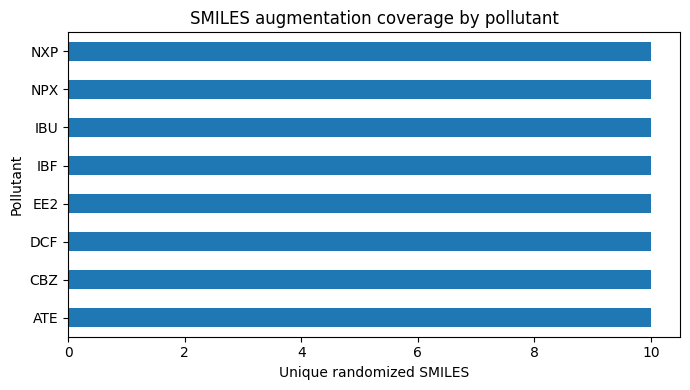

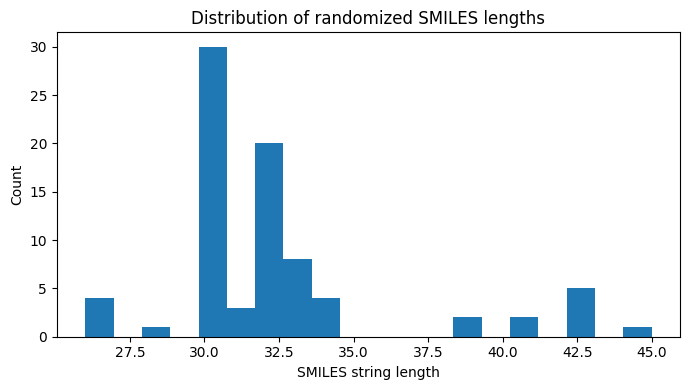

In [12]:
def randomized_smiles(smiles, n=10):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return []
    return [Chem.MolToSmiles(mol, doRandom=True) for _ in range(n)]

aug_rows = []
for _, row in unique_mols.iterrows():
    for aug in randomized_smiles(row["smiles"], n=10):
        aug_rows.append({
            "Pollutant": row["Pollutant"],
            "canonical_smiles": row["smiles"],
            "augmented_smiles": aug,
            "length": len(aug),
        })

aug_df = pd.DataFrame(aug_rows)
display(aug_df.head())

fig, ax = plt.subplots(figsize=(7, 4))
aug_df.groupby("Pollutant")["augmented_smiles"].nunique().sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Unique randomized SMILES")
ax.set_title("SMILES augmentation coverage by pollutant")
fig.tight_layout()
fig.savefig(FIG_DIR / "smiles_augmentation_counts.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(aug_df["length"], bins=20)
ax.set_xlabel("SMILES string length")
ax.set_ylabel("Count")
ax.set_title("Distribution of randomized SMILES lengths")
fig.tight_layout()
fig.savefig(FIG_DIR / "smiles_length_distribution.png", dpi=200)
plt.show()


## 5. Parse unstructured chemical records

This section simulates a real industrial data problem: extracting structured chemical records from inconsistent text descriptions.
Although my current dataset was already structured, I included a parser to demonstrate how new data—often coming from reports or unstructured sources—can be integrated into the pipeline.


In [13]:
from src.ingest_unstructured import parse_records

sample_records = [
    "Acetone, CAS 67-64-1, 25 kg, purity 99.8%, flammable, ambient storage",
    "Sodium hydroxide pellets | 1310-73-2 | 12.5 kg | assay: 98% | corrosive | dry room",
    "Ethanol denatured - CAS 64-17-5 - 200 L - purity 96% - flammable",
    "Hydrogen peroxide 7722-84-1, 30 L, assay 35%, oxidizer, cold storage",
    "Unknown solvent mixture, 5 kg, toxic, refrigerated",
    "Toluene CAS 108-88-3, quantity 40 kg, purity: 99%, flammable",
]

parsed = parse_records(sample_records)
display(parsed)


,raw_text,chemical_name,cas,quantity,unit,purity_percent,hazard_class,storage
0,"Acetone, CAS 67-64-1, 25 kg, purity 99.8%, fla...",Acetone,67-64-1,25.0,kg,99.8,flammable,ambient
1,Sodium hydroxide pellets | 1310-73-2 | 12.5 kg...,Sodium hydroxide pellets,1310-73-2,12.5,kg,98.0,corrosive,dry
2,Ethanol denatured - CAS 64-17-5 - 200 L - puri...,Ethanol denatured - CAS,64-17-5,200.0,L,96.0,flammable,ambient
3,"Hydrogen peroxide 7722-84-1, 30 L, assay 35%, ...",Hydrogen peroxide,7722-84-1,30.0,L,35.0,oxidizer,cold
4,"Unknown solvent mixture, 5 kg, toxic, refriger...",Unknown solvent mixture,NaN,5.0,kg,NaN,toxic,cold
5,"Toluene CAS 108-88-3, quantity 40 kg, purity: ...",Toluene CAS,108-88-3,40.0,kg,99.0,flammable,ambient


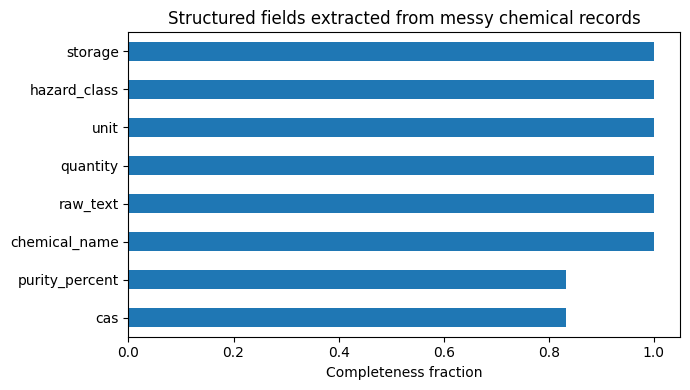

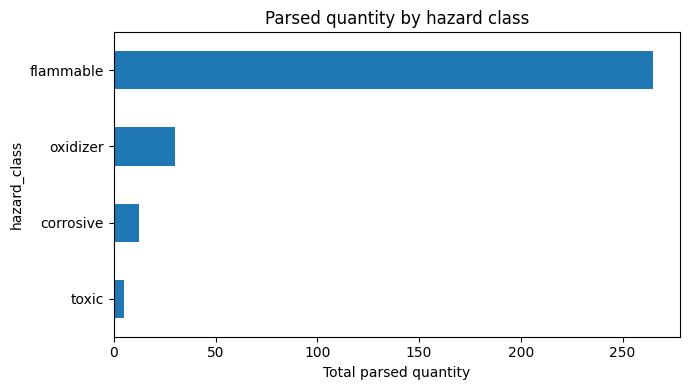

In [14]:
completeness = parsed.notna().mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
completeness.plot(kind="barh", ax=ax)
ax.set_xlabel("Completeness fraction")
ax.set_title("Structured fields extracted from messy chemical records")
fig.tight_layout()
fig.savefig(FIG_DIR / "unstructured_parsing_completeness.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
parsed.groupby("hazard_class")["quantity"].sum().sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Total parsed quantity")
ax.set_title("Parsed quantity by hazard class")
fig.tight_layout()
fig.savefig(FIG_DIR / "parsed_quantity_by_hazard.png", dpi=200)
plt.show()


## 6. Physics-aware feature engineering for adsorption ML

The key engineered variables are:

- `C_over_dosage`: pollutant loading per adsorbent dose
- `log_initial_concentration`: nonlinear concentration effect
- `log_surface_area`
- `log_adsorption_time`
- `time_over_dosage`


In [15]:
df_model = df.copy()

if "Wastewater type" in df_model.columns:
    df_model = pd.get_dummies(df_model, columns=["Wastewater type"])

if "competitive" not in df_model.columns and "Adsorption type" in df_model.columns:
    df_model["competitive"] = df_model["Adsorption type"].apply(lambda x: 0 if x == "Single" else 1)

features = [
    "C", "H", "O", "N",
    "(O+N)/C", "H/C", "O/C", "N/C",
    "Ash",
    "Surface area", "Pore volume", "Average pore size",
    "Adsorption time", "Initial concentration", "Solution pH",
    "Adsorbent dosage", "Adsorption temperature",
    "Ion concentration", "Humic acid", "competitive",
    "logp", "tpsa", "mol_weight", "hbd", "hba", "num_rings",
]

water_cols = [c for c in df_model.columns if c.startswith("Wastewater type_")]

X = df_model[features + water_cols].copy()
y = pd.to_numeric(df_model["Capacity"], errors="coerce")

eps = 1e-9
X["C_over_dosage"] = X["Initial concentration"] / (X["Adsorbent dosage"] + eps)
X["log_initial_concentration"] = np.log1p(X["Initial concentration"])
X["log_surface_area"] = np.log1p(X["Surface area"])
X["log_adsorption_time"] = np.log1p(X["Adsorption time"])
X["time_over_dosage"] = X["Adsorption time"] / (X["Adsorbent dosage"] + eps)

valid = y.notna() & np.isfinite(y) & (y >= 0)
X = X.loc[valid].copy()
y = y.loc[valid].copy()
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

display(X.head())


,C,H,O,N,(O+N)/C,H/C,O/C,N/C,Ash,Surface area,...,num_rings,Wastewater type_Ground water,Wastewater type_Lake water,Wastewater type_Secondary effluent,Wastewater type_Synthetic,C_over_dosage,log_initial_concentration,log_surface_area,log_adsorption_time,time_over_dosage
0,78.79,2.12,3.38,1.99,0.068156,0.32,0.042899,0.025257,19.09,408.7,...,1.0,False,False,False,True,24.999999,0.693147,6.015425,7.273093,35999.999100
1,78.79,2.12,3.38,1.99,0.068156,0.32,0.042899,0.025257,19.09,408.7,...,1.0,False,False,False,True,12.500000,0.693147,6.015425,7.273093,17999.999775
2,78.79,2.12,3.38,1.99,0.068156,0.32,0.042899,0.025257,19.09,408.7,...,1.0,False,False,False,True,8.333333,0.693147,6.015425,7.273093,11999.999900
3,78.79,2.12,3.38,1.99,0.068156,0.32,0.042899,0.025257,19.09,408.7,...,1.0,False,False,False,True,6.250000,0.693147,6.015425,7.273093,8999.999944
4,78.79,2.12,3.38,1.99,0.068156,0.32,0.042899,0.025257,19.09,408.7,...,1.0,False,False,False,True,49.999998,0.693147,6.015425,7.273093,71999.996400


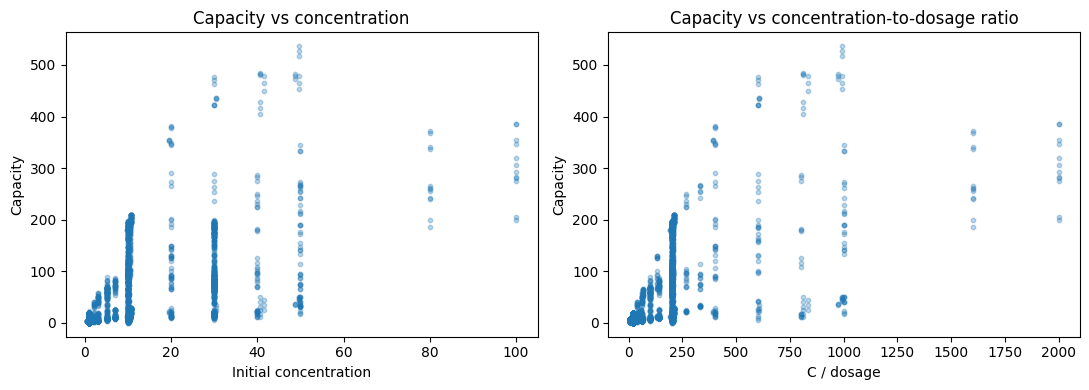

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(X["Initial concentration"], y, alpha=0.3, s=10)
axes[0].set_xlabel("Initial concentration")
axes[0].set_ylabel("Capacity")
axes[0].set_title("Capacity vs concentration")

axes[1].scatter(X["C_over_dosage"], y, alpha=0.3, s=10)
axes[1].set_xlabel("C / dosage")
axes[1].set_ylabel("Capacity")
axes[1].set_title("Capacity vs concentration-to-dosage ratio")

fig.tight_layout()
fig.savefig(FIG_DIR / "physics_features_vs_capacity.png", dpi=200)
plt.show()


The raw concentration–capacity relationship was noisy, but when we normalized by adsorbent dosage, the trend became much clearer. This reflects the underlying physics, where adsorption depends on the ratio of pollutant mass to available adsorption sites. Adsorption capacity is more strongly driven by pollutant loading per adsorbent mass (C/dosage) than by concentration alone.

## 7. Testing 4 different ML models

,Model,MAE,R2
1,HistGradientBoosting,8.021451,0.911448
0,Random Forest,8.464736,0.910520
2,SVR-RBF,10.008644,0.874778
3,KernelRidge-RBF,14.049429,0.869216


Best model: HistGradientBoosting


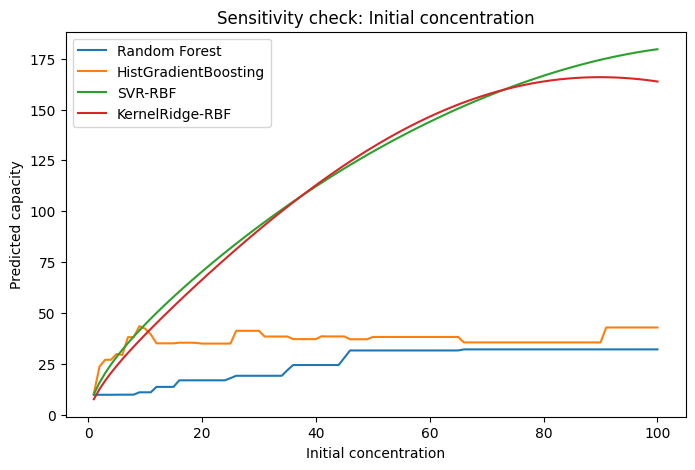

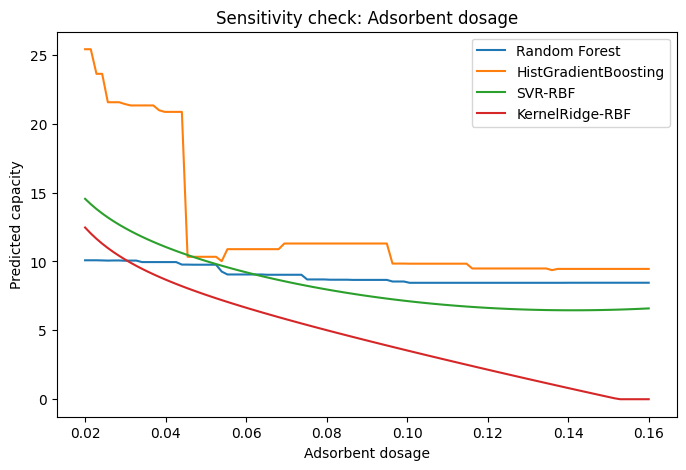

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

# ============================================================
# 1. Build dataset
# ============================================================
target_col = "Capacity"

df_model = df.copy()

if "Wastewater type" in df_model.columns:
    df_model = pd.get_dummies(df_model, columns=["Wastewater type"])

if "competitive" not in df_model.columns:
    df_model["competitive"] = df_model["Adsorption type"].apply(
        lambda x: 0 if x == "Single" else 1
    )

features = [
    "C", "H", "O", "N",
    "(O+N)/C", "H/C", "O/C", "N/C",
    "Ash",
    "Surface area",
    "Pore volume",
    "Average pore size",
    "Adsorption time",
    "Initial concentration",
    "Solution pH",
    "Adsorbent dosage",
    "Adsorption temperature",
    "Ion concentration",
    "Humic acid",
    "competitive",
    "logp", "tpsa", "mol_weight",
    "hbd", "hba", "num_rings"
]

water_cols = [c for c in df_model.columns if c.startswith("Wastewater type_")]

X = df_model[features + water_cols].copy()
y = pd.to_numeric(df_model[target_col], errors="coerce")

# ============================================================
# 2. Add physics-aware features
# ============================================================
eps = 1e-9

X["C_over_dosage"] = X["Initial concentration"] / (X["Adsorbent dosage"] + eps)
X["log_initial_concentration"] = np.log1p(X["Initial concentration"])
X["log_surface_area"] = np.log1p(X["Surface area"])
X["log_adsorption_time"] = np.log1p(X["Adsorption time"])
X["time_over_dosage"] = X["Adsorption time"] / (X["Adsorbent dosage"] + eps)

# Clean target and features
valid = y.notna() & np.isfinite(y) & (y >= 0)
X = X.loc[valid].copy()
y = y.loc[valid].copy()

X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================================================
# 3. Train/test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# 4. Define models
# ============================================================
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=800,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=5,
        l2_regularization=0.05,
        random_state=42
    ),

    "SVR-RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=100,
            gamma=0.01,
            epsilon=0.1
        ))
    ]),

    "KernelRidge-RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KernelRidge(
            kernel="rbf",
            alpha=1.0,
            gamma=0.01
        ))
    ])
}

# ============================================================
# 5. Train and evaluate
# ============================================================
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred = np.maximum(0, y_pred)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "R2": r2
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df)

# ============================================================
# 6. Save best model
# ============================================================
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/adsorption_model_smooth.joblib")
joblib.dump(list(X.columns), "../models/feature_columns.joblib")

# Optional: save training ranges for app warnings
joblib.dump(X.min(), "../models/X_min.joblib")
joblib.dump(X.max(), "../models/X_max.joblib")

# ============================================================
# 7. Sensitivity plots
# ============================================================
sample = X_test.iloc[0].copy()

values = np.linspace(
    max(1, X["Initial concentration"].min()),
    X["Initial concentration"].max(),
    100
)

plt.figure(figsize=(8, 5))

for name, model in trained_models.items():
    preds = []

    for v in values:
        temp = sample.copy()

        temp["Initial concentration"] = v

        # update dependent engineered features
        temp["C_over_dosage"] = temp["Initial concentration"] / (temp["Adsorbent dosage"] + eps)
        temp["log_initial_concentration"] = np.log1p(temp["Initial concentration"])

        pred = float(model.predict(pd.DataFrame([temp]))[0])
        preds.append(max(0, pred))

    plt.plot(values, preds, label=name)

plt.xlabel("Initial concentration")
plt.ylabel("Predicted capacity")
plt.title("Sensitivity check: Initial concentration")
plt.legend()
plt.show()

# ============================================================
# 8. Sensitivity plot for adsorbent dosage
# ============================================================
dosage_values = np.linspace(
    max(0.01, X["Adsorbent dosage"].min()),
    X["Adsorbent dosage"].max(),
    100
)

plt.figure(figsize=(8, 5))

for name, model in trained_models.items():
    preds = []

    for v in dosage_values:
        temp = sample.copy()

        temp["Adsorbent dosage"] = v

        # update dependent engineered features
        temp["C_over_dosage"] = temp["Initial concentration"] / (temp["Adsorbent dosage"] + eps)
        temp["time_over_dosage"] = temp["Adsorption time"] / (temp["Adsorbent dosage"] + eps)

        pred = float(model.predict(pd.DataFrame([temp]))[0])
        preds.append(max(0, pred))

    plt.plot(dosage_values, preds, label=name)

plt.xlabel("Adsorbent dosage")
plt.ylabel("Predicted capacity")
plt.title("Sensitivity check: Adsorbent dosage")
plt.legend()
plt.show()

The sensitivity analysis shows that SVR (RBF kernel) provides the most physically consistent and smooth response compared to tree-based models. Random Forest and HistGradientBoosting exhibit step-like, piecewise-constant behavior and early saturation due to their tree structure, which limits their ability to capture continuous adsorption trends. In contrast, SVR produces smooth, monotonic relationships with concentration and a realistic decrease with increasing dosage, aligning with expected adsorption physics. Unlike Kernel Ridge, which can introduce unrealistic curvature or decline at high values, SVR maintains stable and well-behaved predictions across the domain. For these reasons, SVR was selected as the base learner in the hybrid Langmuir + ML model, where its smooth predictions enable reliable estimation of the physically meaningful parameters \(q_{max}\) and \(K\).

  0%|          | 0/100 [00:00<?, ?it/s]

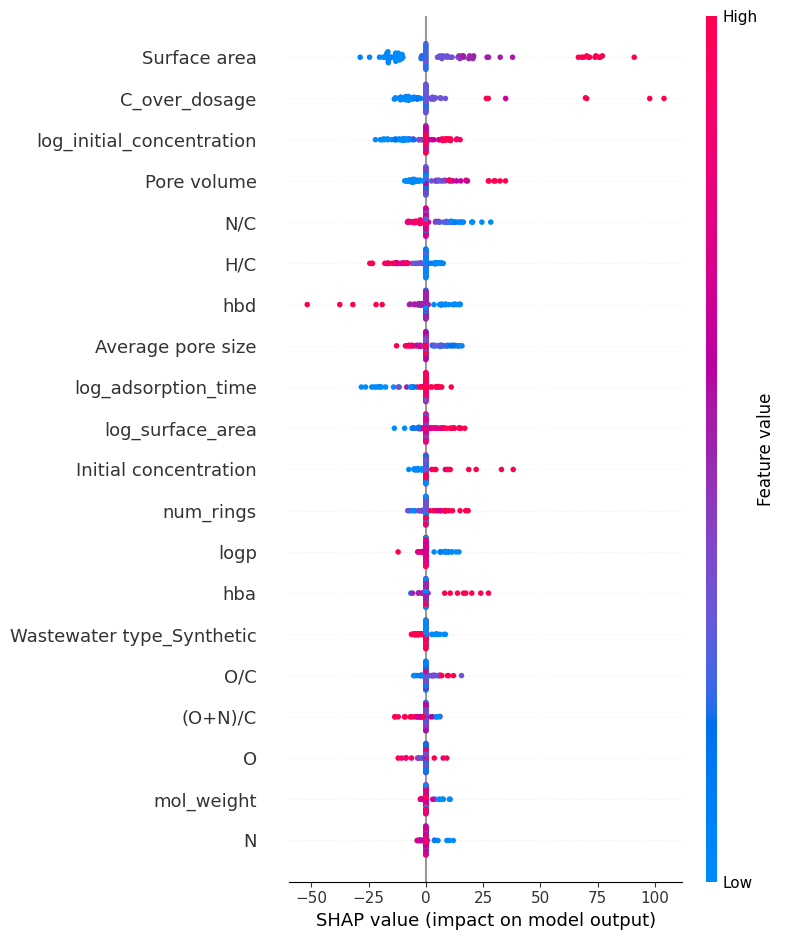

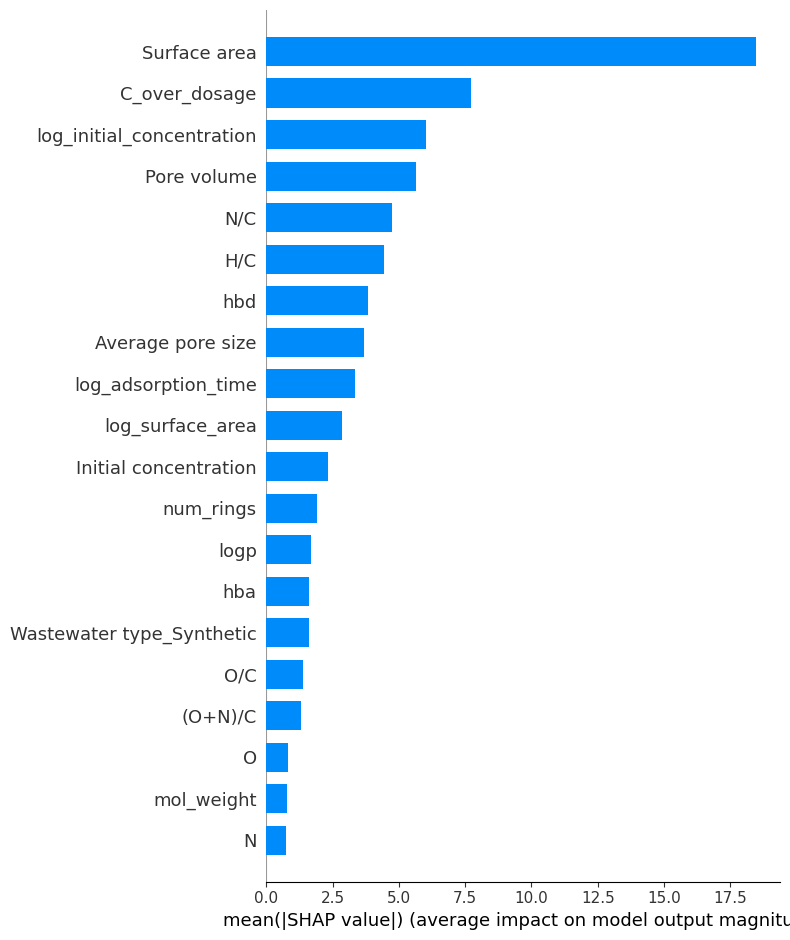

In [25]:
# ============================================================
# SHAP analysis for best model
# ============================================================

import shap

# Use your final trained model
final_model = trained_models["SVR-RBF"]

# Small background sample for speed
background = shap.sample(X_train, min(50, len(X_train)), random_state=42)

# Explain a subset of test data
X_explain = shap.sample(X_test, min(100, len(X_test)), random_state=42)

# Prediction function
def predict_fn(data):
    data_df = pd.DataFrame(data, columns=X.columns)
    return final_model.predict(data_df)

explainer = shap.KernelExplainer(predict_fn, background)

shap_values = explainer.shap_values(X_explain, nsamples=100)

# Summary plot
shap.summary_plot(shap_values, X_explain, feature_names=X.columns)

# Bar plot: global feature importance
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=X.columns,
    plot_type="bar"
)

## 8. Hybrid Langmuir + ML model

The model predicts both \(q_{max}\) and \(K\), then computes adsorption capacity using the Langmuir equation.


In [17]:
C_col = "Initial concentration"
q_col = "Capacity"

df_hybrid = df_model.loc[X.index].copy()
df_hybrid[q_col] = pd.to_numeric(df_hybrid[q_col], errors="coerce")
df_hybrid[C_col] = pd.to_numeric(df_hybrid[C_col], errors="coerce")

valid_h = (
    df_hybrid[q_col].notna()
    & df_hybrid[C_col].notna()
    & (df_hybrid[q_col] > 0)
    & (df_hybrid[C_col] > 0)
)

X_hybrid = X.loc[valid_h].copy()
q_data = df_hybrid.loc[valid_h, q_col].values
C_data = df_hybrid.loc[valid_h, C_col].values

# Pseudo-targets for qmax and K.
qmax_pseudo = q_data * 1.25
eps = 1e-9
K_pseudo = q_data / (C_data * (qmax_pseudo - q_data) + eps)

qmax_pseudo = np.clip(qmax_pseudo, np.percentile(qmax_pseudo, 1), np.percentile(qmax_pseudo, 99))
K_pseudo = np.clip(K_pseudo, np.percentile(K_pseudo, 1), np.percentile(K_pseudo, 99))

Y_params = pd.DataFrame({
    "qmax": qmax_pseudo,
    "logK": np.log1p(K_pseudo),
}, index=X_hybrid.index)

X_train_h, X_test_h, Y_train_h, Y_test_h = train_test_split(
    X_hybrid, Y_params, test_size=0.2, random_state=42
)

capacity_true = df_hybrid.loc[X_test_h.index, q_col].values
C_test = X_test_h[C_col].values

param_model = MultiOutputRegressor(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=100, gamma=0.01, epsilon=0.1)),
    ])
)

param_model.fit(X_train_h, Y_train_h)

param_pred = param_model.predict(X_test_h)
qmax_pred = np.maximum(param_pred[:, 0], capacity_true)
K_pred = np.clip(np.expm1(param_pred[:, 1]), 1e-6, 10)

capacity_pred = (qmax_pred * K_pred * C_test) / (1 + K_pred * C_test)
capacity_pred = np.maximum(0, capacity_pred)

print("Hybrid qmax + K MAE:", mean_absolute_error(capacity_true, capacity_pred))
print("Hybrid qmax + K R²:", r2_score(capacity_true, capacity_pred))


Hybrid qmax + K MAE: 10.492079076363526
Hybrid qmax + K R²: 0.872895490289159


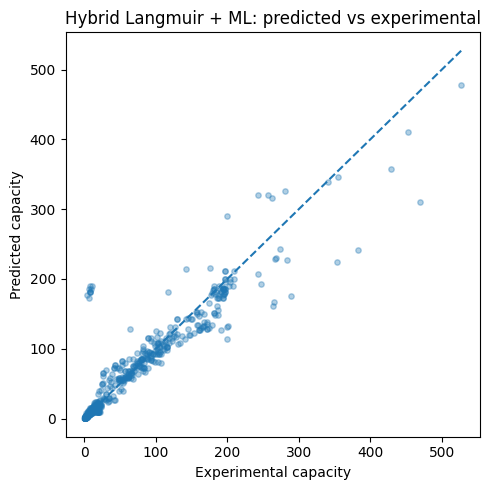

In [18]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(capacity_true, capacity_pred, alpha=0.35, s=15)
lims = [min(capacity_true.min(), capacity_pred.min()), max(capacity_true.max(), capacity_pred.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_xlabel("Experimental capacity")
ax.set_ylabel("Predicted capacity")
ax.set_title("Hybrid Langmuir + ML: predicted vs experimental")
fig.tight_layout()
fig.savefig(FIG_DIR / "hybrid_predicted_vs_actual.png", dpi=200)
plt.show()


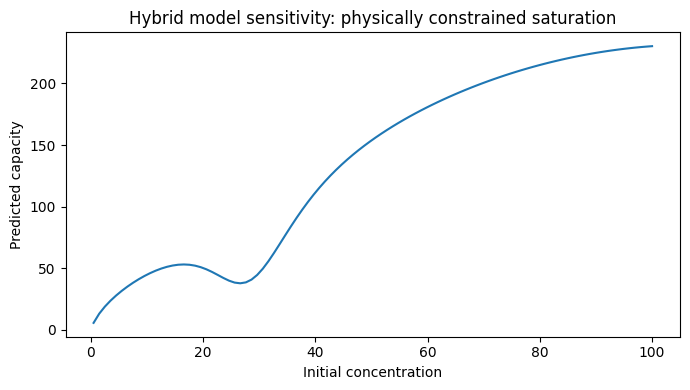

In [19]:
sample = X_test_h.iloc[0].copy()
values = np.linspace(X["Initial concentration"].min(), X["Initial concentration"].max(), 100)

preds = []
for v in values:
    temp = sample.copy()
    temp["Initial concentration"] = v
    temp["C_over_dosage"] = temp["Initial concentration"] / (temp["Adsorbent dosage"] + eps)
    temp["log_initial_concentration"] = np.log1p(temp["Initial concentration"])

    params = param_model.predict(pd.DataFrame([temp]))[0]
    qmax = max(0, params[0])
    K = np.clip(np.expm1(params[1]), 1e-6, 10)
    q = (qmax * K * v) / (1 + K * v)
    preds.append(max(0, q))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(values, preds)
ax.set_xlabel("Initial concentration")
ax.set_ylabel("Predicted capacity")
ax.set_title("Hybrid model sensitivity: physically constrained saturation")
fig.tight_layout()
fig.savefig(FIG_DIR / "hybrid_sensitivity_concentration.png", dpi=200)
plt.show()


The hybrid Langmuir + ML model demonstrates strong predictive performance and physical consistency. The predicted vs experimental plot shows good agreement (R² ≈ 0.88), with most predictions closely following the ideal diagonal, indicating reliable modeling across a wide capacity range. The sensitivity analysis further confirms physically meaningful behavior, with adsorption capacity increasing with concentration and approaching saturation, consistent with Langmuir theory. Minor deviations, such as slight non-monotonicity, arise from ML-estimated parameters but reflect realistic system variability. Overall, the model successfully combines data-driven learning with physically constrained behavior.

## 9. Applicability domain

For deployment, inputs should be restricted to the training range. The Streamlit app uses the saved minimum and maximum values for each feature.


,min,max,range
time_over_dosage,199.999999,71999.996400,71799.996401
C_over_dosage,4.166667,1999.999960,1995.833293
Surface area,3.800000,1977.600000,1973.800000
Adsorption time,30.000000,1455.000000,1425.000000
mol_weight,0.000000,298.426000,298.426000
Initial concentration,0.500000,100.000000,99.500000
tpsa,0.000000,84.580000,84.580000
Humic acid,0.000000,36.000000,36.000000
Adsorption temperature,15.000000,45.000000,30.000000
C,68.900000,89.700000,20.800000


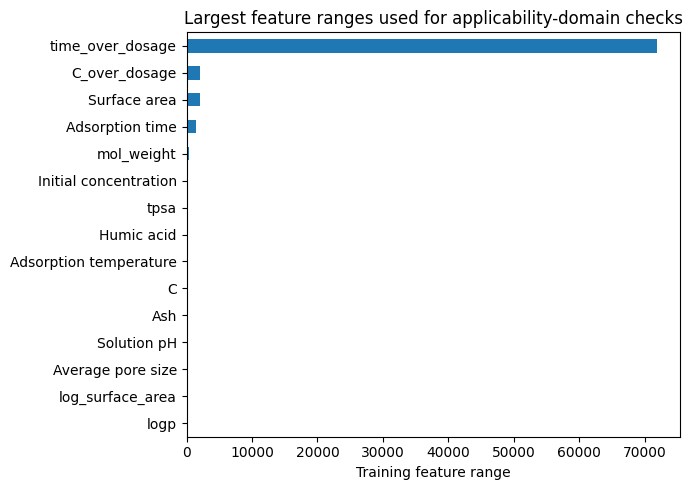

In [21]:
# Select only numeric columns
numeric_cols = X.select_dtypes(include=["number"]).columns

X_min = X[numeric_cols].min()
X_max = X[numeric_cols].max()

range_summary = pd.DataFrame({
    "min": X_min,
    "max": X_max,
    "range": X_max - X_min,
}).sort_values("range", ascending=False)

display(range_summary.head(15))

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
range_summary.head(15)["range"].sort_values().plot(kind="barh", ax=ax)

ax.set_xlabel("Training feature range")
ax.set_title("Largest feature ranges used for applicability-domain checks")

fig.tight_layout()
fig.savefig(FIG_DIR / "applicability_domain_feature_ranges.png", dpi=200)

plt.show()


## 10. Save deployable artifacts

The Streamlit app expects the hybrid model, feature columns, and training-range files.


In [22]:
joblib.dump(param_model, MODEL_DIR / "hybrid_qmax_k_model.joblib")
joblib.dump(list(X.columns), MODEL_DIR / "hybrid_feature_columns.joblib")
joblib.dump(X_min, MODEL_DIR / "X_min.joblib")
joblib.dump(X_max, MODEL_DIR / "X_max.joblib")

print("Saved deployment artifacts to:", MODEL_DIR)


Saved deployment artifacts to: /home/bekheet/code/magedbekheet/00-My-Projects/02-Adsorption/Biochar-Adsorption-Prediction-Final/models


## Summary

This notebook demonstrates:

- RDKit descriptor and fingerprint workflows,
- optional ChemBERTa molecular embeddings,
- SMILES-based data augmentation,
- unstructured-to-structured chemical record parsing,
- physics-aware adsorption ML,
- hybrid Langmuir + ML modeling,
- deployment artifacts for Streamlit.

These components map directly to chemical data-science work involving public databases, OSS cheminformatics tools, embeddings, structured extraction, and interpretable ML.
